## `emulate_hsc.ipynb` 

This notebook simulates how we extract from Buzzard Mocks an HSC-type catalog by mimicking the selection of HSC.

Idea :
- Bin HSC sources on a high-resolution healpix map to infer source density
- Draw N sources respecting the catalog magnitude distributions
- Assert it is correct by comparing to the true catalog 

## Step 1 : Binning HSC sources on a healpix map

In [55]:
# imports
import fitsio as fio 
import numpy as np 
import healpy as hp
import cmocean.cm as cmo
import matplotlib.pyplot as plt

from numpy.lib import recfunctions as rfn
from astropy.table import Table, vstack
from pathlib import Path

# tools
import simtools as simt

In [56]:
# Some interface to get the buzzard catalog
bc = simt.BuzzardCatalog(buzzard_index=4)
# weird facts :
# surveymags and truth are in addgalspostprocess
# buzzard-9 is empty ??
# some generally weird directory structures there, not quite sure why.
pix = 0
# testing the files are available
mag = bc.fetch_surveymag(pix=pix)
true = bc.fetch_truth(pix=pix)
tgt = bc.fetch_desi_target(pix=pix)
filters = np.loadtxt('filters.txt', dtype=str)
mag_index = list(filters).index('DECAM_i')

First thing to do is (according to Li et al, 2022) "In addition, we remove a region in GAMA09H with 132.5 <
ra < 140 [deg], 1.6 < dec < 5 [deg], containing an area of ∼20 deg^2."

In [57]:
## Get HSC coordinates
hsc_tbl_all = fio.FITS(simt.HSC_CATALOG)
ra_uncut = hsc_tbl_all[1]['RA'].read()
dec_uncut = hsc_tbl_all[1]['DEC'].read()

all_ra_length = len(ra_uncut)
all_dec_length = len(dec_uncut)
# returns True if the pixel is not in the area we want to remove
gama09H_mask =  ~(
    (1.6 < dec_uncut) & (dec_uncut < 5) & (132.5 < ra_uncut) & (ra_uncut < 140)
    )

ra_cut = ra_uncut[gama09H_mask]
dec_cut = dec_uncut[gama09H_mask]

print(
    f"Cutting the catalog from {all_ra_length} to {len(ra_cut)} "
    f"[reduction of {1 - len(ra_cut) / all_ra_length:.2%}]"
    )

Cutting the catalog from 34407034 to 34407034 [reduction of 0.00%]


There's a reduction of 0% so we don't really care about that cut.

now, let's displace the HSC field temporarily into the Buzzard region to make our mock dataset; by sampling the footprint. We assert there's decent separation (a few degrees) and no overlap between the moved fields.
Values : 
- +80/35 RA/DEC for field 1
- +260/20 RA/DEC for field 2

In [50]:
# We move HSC coordinates to a location on the sky covered by Buzzard mocks (NW corner)
# We do field by field and join afterwards the catalogs. Once the field is moved, 
# sample on where buzzard actually is by limiting ra, dec coordinates

# first patch : 80, 35, second patch : 260, 20
offset_ra = 80
offset_dec = 35 
patch_id = 1
# careful that we don't deal with dec > 90 and hsc goes up to dec ~45
# so this means we are limited to a dec offset of 30ish at most

# moving coordinates to the field where Buzzard is located
ra_all = (ra_cut + offset_ra) % 360
dec_all = dec_cut + offset_dec
# assert we are not going over dec > 90 in the process so that we don't shift the field outside bounds
assert np.sum(dec_all > 90) == 0
# limiting ourselves to the NW corner
# keeping the displaced HSC areathat is in 
bds_mask = (0 < ra_all) & (ra_all < 180) & (0 < dec_all)
ra_hsc = ra_all[bds_mask]
dec_hsc = dec_all[bds_mask]

In [51]:
oid = hsc_tbl_all[1]['object_id'].read()
# check that we are not duplicating objects
assert len(oid) == len(np.unique(oid))
print(f'Number of objects in HSC : {len(oid)}')

Number of objects in HSC : 34407034


There is a 'use_bmode_flag' flag. Assert that this flag is due to the (Li & al 2022) criteria

In [52]:
tbl_nobmode_cut = fio.FITS(
    simt.HSC_CATALOG.parent / 'hscy3_cat_no_bmode_cut.fits'
)
ra_nbc = tbl_nobmode_cut[1]['RA'].read()
dec_nbc = tbl_nobmode_cut[1]['DEC'].read()

all_ra_length_nbc = len(ra_nbc)
all_dec_length_nbc = len(dec_nbc)
# returns True if the pixel is not in the area we want to remove
gama09H_mask_nbc =  ~(
    (1.6 < dec_nbc) & (dec_nbc < 5) & (132.5 < ra_nbc) & (ra_nbc < 140)
    )
# this is equal to the number of objects in the catalog with the 'bmode' cut so all good !
print(
    f'{np.sum(gama09H_mask_nbc)} objects in the bmode cut out of {all_ra_length_nbc}, '
    f'removing [{(1 - np.sum(gama09H_mask_nbc) / all_ra_length_nbc):.2%}].\n'
    f'With the bmode cut, we have : {len(ra_all)} objects. '
    )

34407034 objects in the bmode cut out of 35805482, removing [3.91%].
With the bmode cut, we have : 34407034 objects. 


Plot the displaced HSC catalog

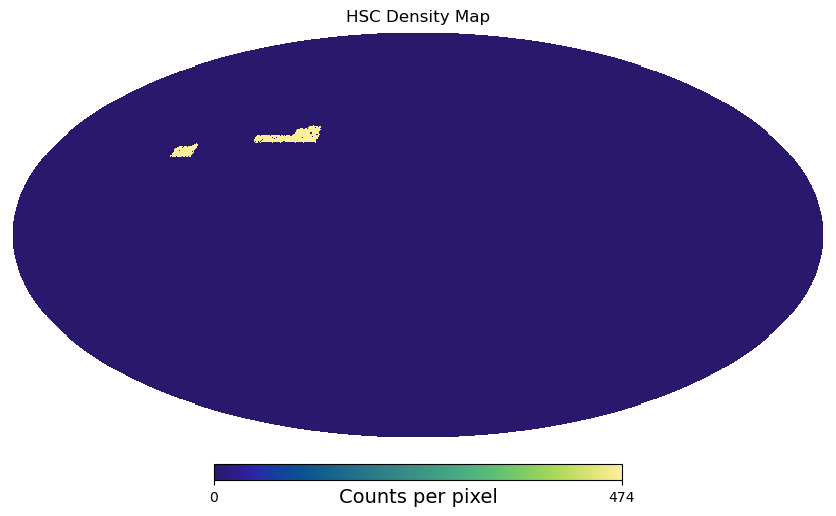

/tmp/ipykernel_1471766/669347990.py:33: RuntimeWarning: divide by zero encountered in log10
  np.log10(hsc_hp_map),


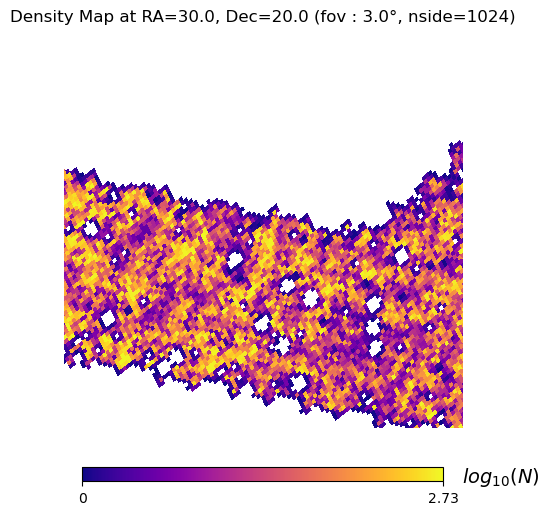

In [53]:
# very important : this determines local density of the map.
# in theory, we want it very high to accurately mimic survey sample
nside_hsc = 1024

npix_hsc = hp.nside2npix(nside_hsc)
theta = np.radians(90.0 - dec_hsc) 
phi = np.radians(ra_hsc)
hsc_pix_indices = hp.ang2pix(nside_hsc, theta, phi, nest=True)
hsc_hp_map = np.bincount(hsc_pix_indices, minlength=npix_hsc)

hp.mollview(
    hsc_hp_map,
    title="HSC Density Map",
    unit="Counts per pixel",
    norm="hist",
    cmap=cmo.haline,
    nest=True,
)
plt.show()

# === Zoom configuration ===
if patch_id == 1:
    center_ra = 30.0  
    center_dec = 20.0
    half_width = 3.0
elif patch_id == 2:
    center_ra = 20.0
    center_dec = 11.0
    half_width = 3.0
# ==========================

hp.cartview(
    np.log10(hsc_hp_map),
    lonra=[center_ra - half_width, center_ra + half_width],
    latra=[center_dec - half_width, center_dec + half_width],
    rot=(center_ra, center_dec),
    title=f"Density Map at RA={center_ra}, Dec={center_dec} (fov : {half_width}°, nside={nside_hsc})",
    unit=r"$log_{\rm{10}}(N)$",
    norm="hist",
    cmap='plasma',
    nest=True,
    cbar=True,
)

Showcase which buzzard pixels are used and which are available.

13 low-res pixels are covered.
List: [13 17 18 19 20 22 24 25 26 96 97 98 99]


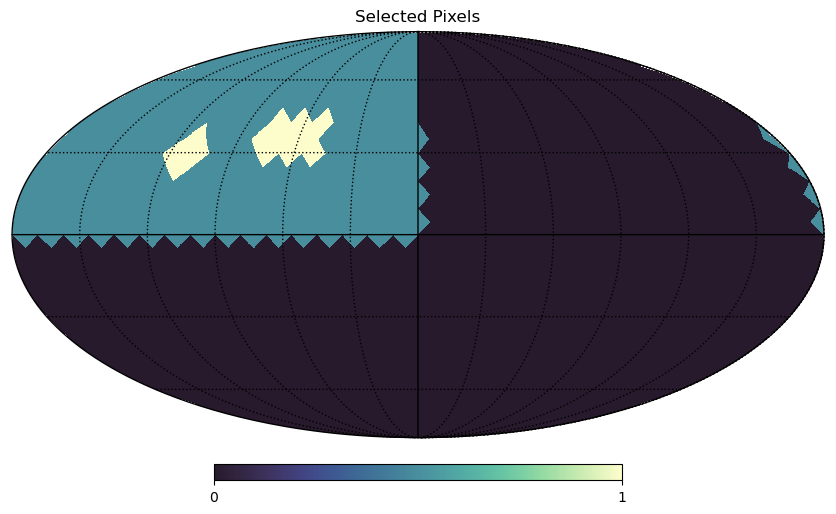

In [54]:
nside_buzzard = bc.nside_buzzard

map_low = np.zeros(hp.nside2npix(nside_buzzard))
nonzero_high = np.flatnonzero(hsc_hp_map > 0)

theta, phi = hp.pix2ang(nside_hsc, nonzero_high, nest=True)

low_pixels = hp.ang2pix(nside_buzzard, theta, phi, nest=True)
unique_low_pixels = np.unique(low_pixels)

print(f"{len(unique_low_pixels)} low-res pixels are covered.")
print("List:", unique_low_pixels)

npix = hp.nside2npix(nside_buzzard)
hmap = np.zeros(npix)
pix_nums = sorted([int(pix.name.split('.')[1]) for pix in bc.files_pix])
# Set value 1.0 for the selected pixels
hmap[pix_nums] = 0.5
hmap[unique_low_pixels] = 1

# Plot the map
hp.mollview(hmap, title="Selected Pixels", nest=True, cmap=cmo.deep_r)
hp.graticule()
plt.show()

#### Check patch overlap

------------------------

Assert that moving the HSC patches into the NW quadrant does not have overlap so we don't probe the same sources twice.

In [70]:
npix_hsc = hp.nside2npix(nside_hsc)

ra_hsc1 = (ra_cut + 80) % 360
dec_hsc1 = dec_cut + 35

ra_hsc2 = (ra_cut + 260) % 360
dec_hsc2 = dec_cut + 20

bds_mask1 = (0 < ra_hsc1) & (ra_hsc1  < 180) & (0 < dec_hsc1)
bds_mask2 = (0 < ra_hsc2) & (ra_hsc2  < 180) & (0 < dec_hsc2)
ra_hsc1 = ra_hsc1[bds_mask1]
dec_hsc1 = dec_hsc1[bds_mask1]
ra_hsc2 = ra_hsc2[bds_mask2]
dec_hsc2 = dec_hsc2[bds_mask2]

theta1 = np.radians(90.0 - dec_hsc1) 
phi1 = np.radians(ra_hsc1)
hsc_pix_indices1 = hp.ang2pix(nside_hsc, theta1, phi1, nest=True)
hsc_hp_map1 = np.bincount(hsc_pix_indices1, minlength=npix_hsc)

theta2 = np.radians(90.0 - dec_hsc2)
phi2 = np.radians(ra_hsc2)
hsc_pix_indices2 = hp.ang2pix(nside_hsc, theta2, phi2, nest=True)
hsc_hp_map2 = np.bincount(hsc_pix_indices2, minlength=npix_hsc)

Check the covered region in the buzzard MOC for HSC, check if there's no overlap in between the samples.

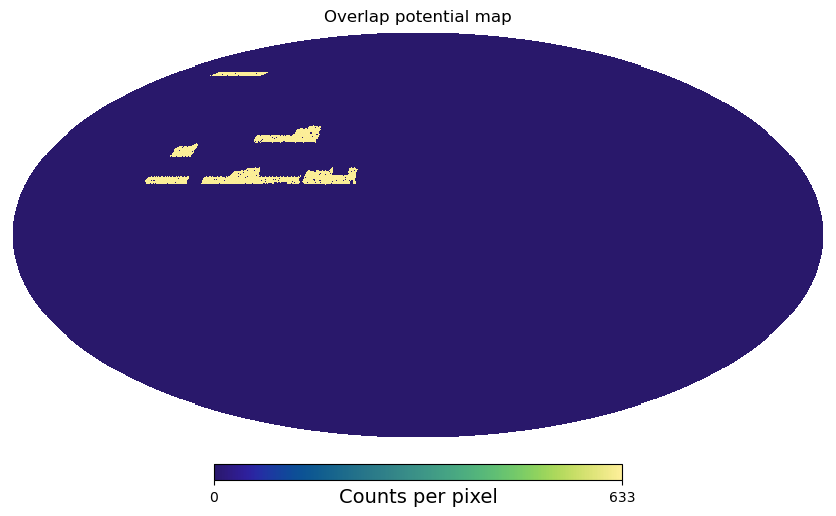

In [71]:
hp.mollview(
    hsc_hp_map1+hsc_hp_map2,
    title="Overlap potential map",
    unit="Counts per pixel",
    norm="hist",
    cmap=cmo.haline,
    nest=True,
)

Check needed overlap on buzzard pixels

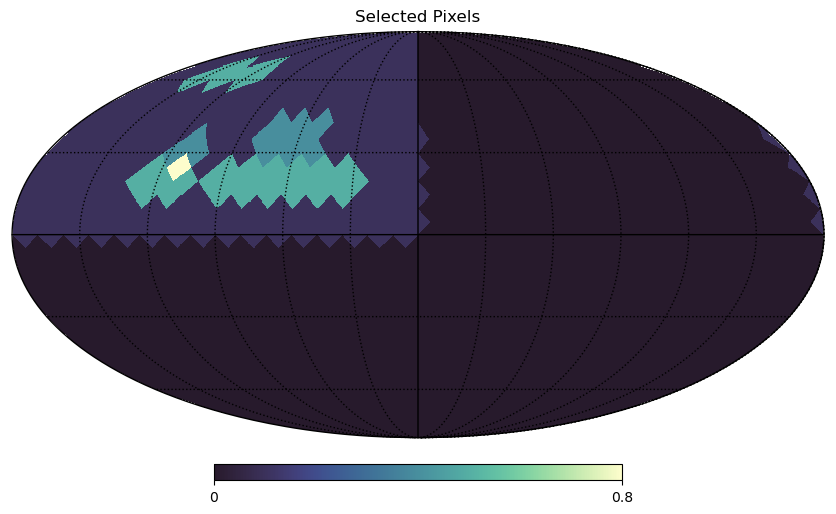

In [73]:
nside_buzzard = bc.nside_buzzard

low_pixels1 = hp.ang2pix(nside_buzzard, theta1, phi1, nest=True)
unique_low_pixels1 = np.unique(low_pixels1)
low_pixels2 = hp.ang2pix(nside_buzzard, theta2, phi2, nest=True)
unique_low_pixels2 = np.unique(low_pixels2)

npix = hp.nside2npix(nside_buzzard)
hmap = np.zeros(npix)
pix_nums = sorted([int(pix.name.split('.')[1]) for pix in bc.files_pix])
# Set value 1.0 for the selected pixels
hmap[pix_nums] += 0.1
hmap[unique_low_pixels1] += 0.3
hmap[unique_low_pixels2] += 0.4

# Plot the map
hp.mollview(hmap, title="Selected Pixels", nest=True, cmap=cmo.deep_r)
hp.graticule()
plt.show()

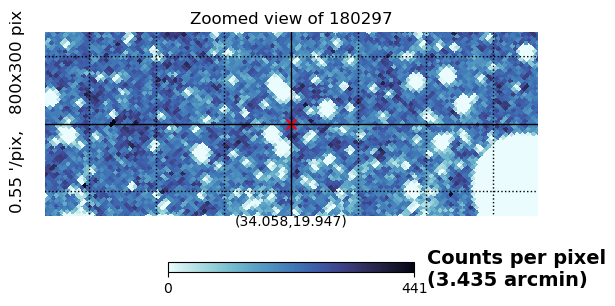

In [40]:
pixel_to_zoom = np.random.choice(nonzero_high, 1)[0]
theta, phi = hp.pix2ang(nside_hsc, pixel_to_zoom, nest=True)

lon = np.degrees(phi)
lat = 90 - np.degrees(theta)

hp.gnomview(
    hsc_hp_map, 
    rot=(lon, lat),  
    xsize=800,
    ysize=300,
    reso=0.55,
    title=f"Zoomed view of {pixel_to_zoom}",
    unit=f"Counts per pixel\n({hp.nside2resol(nside_hsc, arcmin=True):.3f} arcmin)",
    cmap=cmo.ice_r, 
    nest=True
)
hp.projscatter([theta], [phi], lonlat=False, color='red', marker='x', s=50)
hp.graticule()
plt.show()

In [42]:
calhsc = fio.FITS(
    '/global/cfs/cdirs/desi/users/cblake/lensing/mock_inputs/hsc_cal.fits'
)
maghsc = fio.FITS(
    '/global/cfs/cdirs/desi/users/cblake/lensing/mock_inputs/hsc_mag.fits'
)

In [43]:
# get an example of the mock catalog pixel truth to sample it's magnitude distribution
sim_all = fio.FITS(bc.fetch_truth(pix=0))
i_sim_mag_all = sim_all[1]['LMAG'].read()[:, mag_index]
# read the Y1 calibration file
i_cmag_fromcal = maghsc[1]['icmodel_mag'].read()
# read the HSC catalog cmodel and aperture magnitudes
i_cmag = hsc_tbl_all[1]['i_cm_mag'].read()
i_aperture = hsc_tbl_all[1]['i_aperture_mag'].read()

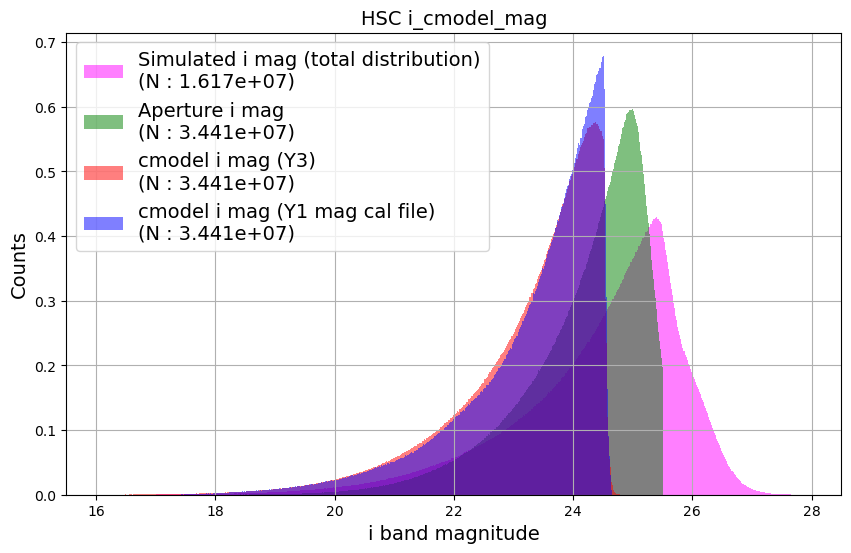

In [45]:
bins_imag = 1000
plt.figure(figsize=(10, 6))
plt.hist(
    i_sim_mag_all, 
    bins=bins_imag, 
    label=f'Simulated i mag (total distribution)\n(N : {len(i_sim_mag_all):.3e})', 
    alpha=0.5, 
    color='magenta',
    density=True
    )
plt.hist(
    i_aperture, 
    bins=bins_imag, 
    label=f'Aperture i mag\n(N : {len(i_aperture):.3e})', 
    alpha=0.5, 
    color='green',
    density=True
    )
plt.hist(
    i_cmag, 
    bins=bins_imag, 
    label=f'cmodel i mag (Y3)\n(N : {len(i_cmag):.3e})', 
    alpha=0.5, 
    color='red',
    density=True
    )
plt.hist(
    i_cmag_fromcal, 
    bins=bins_imag, 
    label=f'cmodel i mag (Y1 mag cal file)\n(N : {len(i_cmag):.3e})', 
    alpha=0.5, 
    color='blue', 
    density=True
    )
plt.grid()
plt.xlabel('i band magnitude', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.title('HSC i_cmodel_mag', fontsize=14)
plt.xlim(15.5, 28.5)
plt.legend(fontsize=14)

In [74]:
# assert there are no NaN values in the magnitude array
i_cmag_fromtbl = hsc_tbl_all[1]['i_cm_mag'].read()
mag_mask = ~np.isnan(i_cmag_fromtbl)
print(
    f'Ns : {np.sum(mag_mask)}/ {len(i_cmag_fromtbl)} ' 
    f'(percentage : {np.sum(mag_mask)/len(i_cmag_fromtbl)*100:.2f}%)'
    )

Ns : 34407034/ 34407034 (percentage : 100.00%)


Open redshift information and display it

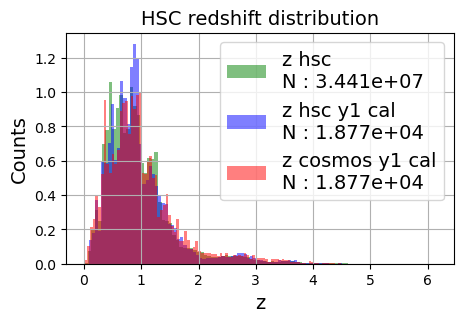

In [46]:
plt.figure(figsize=(5, 3))
redhsc = calhsc[1]['redhsc'].read()
redcosmos = calhsc[1]['redcosmos'].read()
z_hsc = hsc_tbl_all[1]['dnnz_photoz_best'].read()

plt.hist(
    z_hsc, 
    bins=100, 
    label=f'z hsc\nN : {len(z_hsc):.3e}', 
    alpha=0.5, 
    color='green', 
    density=True
    )
plt.hist(
    redhsc, 
    bins=100, 
    label=f'z hsc y1 cal\nN : {len(redhsc):.3e}', 
    alpha=0.5, 
    color='blue',
    density=True
    )
plt.hist(
    redcosmos, 
    bins=100, 
    label=f'z cosmos y1 cal\nN : {len(redcosmos):.3e}', 
    alpha=0.5, 
    color='red',
    density=True
    )
plt.xlabel('z', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.title('HSC redshift distribution', fontsize=14)
plt.grid()
plt.legend(fontsize=14)

In [47]:
# now that this part of the HSC field lands in the buzzard field,
# we can generate our emulated HSC catalog. 

# For each pixel that we have in the HSC catalog, we grab the corresponding tile
# from the Buzzard catalog. 
tiles_nonnull_hsc = np.flatnonzero(hsc_hp_map > 0)
theta, phi = hp.pix2ang(nside_hsc, tiles_nonnull_hsc, nest=True)
tiles_buzzard = hp.ang2pix(nside_buzzard, theta, phi, nest=True)

tiles_buzzard_to_hsc = {}
for t_buzzard, t_hsc in zip(tiles_buzzard, tiles_nonnull_hsc):
    try:
        tiles_buzzard_to_hsc[t_buzzard].append(t_hsc)
    except KeyError:
        tiles_buzzard_to_hsc[t_buzzard] = [t_hsc]

# Getting the DESI targets in the same footprint

-------------------------------------------------

We sample the desi target files to extract sources flagged as belonging to the DESI sample simulations

In [140]:
tbpix_keys = list(tiles_buzzard_to_hsc.keys())
target = []
outdir = f'desi{patch_id}/temp_tiles/'
Path(outdir).mkdir(parents=True, exist_ok=True)

for index, (tbpix, thpixs) in enumerate(tiles_buzzard_to_hsc.items()):
    print(
        f"Processing tile {tbpix} with {len(thpixs)} HSC tiles ({index+1}/{len(tbpix_keys)})"
        )
    with fio.FITS(bc.fetch_desi_target(tbpix)) as f:
        # just read the full thing idk
        target = f[1].read()
        ra_target = target['ra']
        dec_target = target['dec']
        theta_target = np.radians(90.0 - dec_target)
        phi_target = np.radians(ra_target)

    pix_truth_hsc = hp.ang2pix(nside_hsc, theta_target, phi_target, nest=True)
    print(
        f"Found {len(target)} desi target sources in tile {tbpix}. Finished loading files\n"
        )
    
    mid_target = []

    for k, thp in enumerate(thpixs):

        in_thp = pix_truth_hsc == thp
        indices_in_thp = np.where(in_thp)[0]

        if k % int(len(thpixs)//5) == 0:
            print(
                f"Tile {thp} has {len(indices_in_thp)} sources, "
                f"progress {k}/{len(thpixs)} [{100*(k+1)/len(thpixs):.1f}%]"
                )
        mid_target.append(target[in_thp])
            
    # Concatenate the results
    tile_truth_table = Table(np.concatenate(mid_target))
    tile_truth_table['ra'] -= offset_ra
    tile_truth_table['dec'] -= offset_dec
    tile_truth_table.write(f"{outdir}/tile_{tbpix}.fits", overwrite=True)

tables = [Table.read(f) for f in Path(outdir).glob("*.fits")]
final_table = vstack(tables)
print(f"Final table has {len(final_table)} sources")
final_table.write(f'desi{patch_id}/test_desi_targets.fits', overwrite=True)

Processing tile 3 with 293 HSC tiles (1/31)
Found 173993 desi target sources in tile 3. Finished loading files

Tile 64885 has 7 sources, progress 0/293 [0.3%]
Tile 65241 has 18 sources, progress 58/293 [20.1%]
Tile 65329 has 19 sources, progress 116/293 [39.9%]
Tile 65397 has 12 sources, progress 174/293 [59.7%]
Tile 65463 has 9 sources, progress 232/293 [79.5%]
Tile 65532 has 4 sources, progress 290/293 [99.3%]
Processing tile 4 with 281 HSC tiles (2/31)
Found 177969 desi target sources in tile 4. Finished loading files

Tile 81278 has 5 sources, progress 0/281 [0.4%]
Tile 81640 has 8 sources, progress 56/281 [20.3%]
Tile 81732 has 11 sources, progress 112/281 [40.2%]
Tile 81798 has 8 sources, progress 168/281 [60.1%]
Tile 81861 has 10 sources, progress 224/281 [80.1%]
Tile 81919 has 12 sources, progress 280/281 [100.0%]
Processing tile 5 with 6150 HSC tiles (3/31)
Found 183981 desi target sources in tile 5. Finished loading files

Tile 85867 has 7 sources, progress 0/6150 [0.0%]
Til

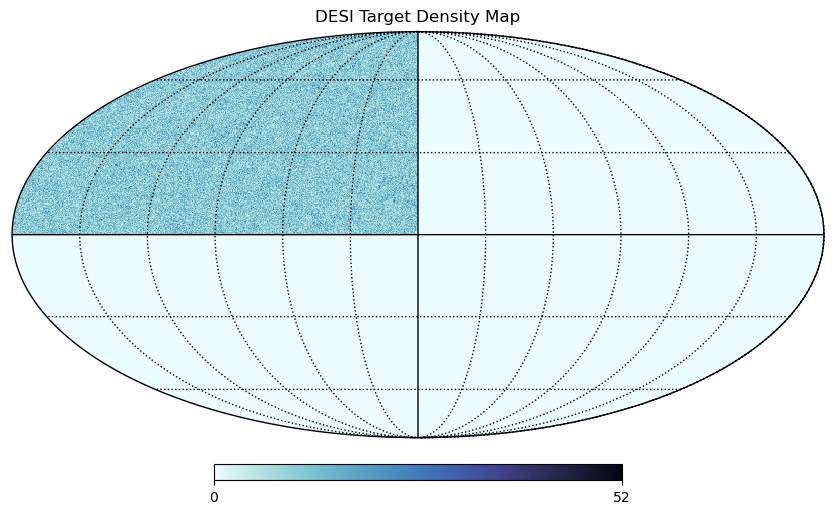

In [141]:
# display DESI target density map
all_pix_truth_desi = []
for indexpix, pix in enumerate(list(bc.pix_nums)):
    with fio.FITS(bc.fetch_desi_target(pix)) as f:
        ra = f[1]['RA'].read()
        dec = f[1]['DEC'].read()
        theta = np.radians(90.0 - dec)
        phi = np.radians(ra)
        pix_truth_desi = hp.ang2pix(nside_hsc, theta, phi, nest=True)
        all_pix_truth_desi.extend(pix_truth_desi)

all_pix_truth_desi = np.array(all_pix_truth_desi)
npix = hp.nside2npix(nside_hsc)
density_map = np.bincount(all_pix_truth_desi, minlength=npix)

hp.mollview(density_map, nest=True, cmap=cmo.ice_r, title='DESI Target Density Map')
hp.graticule()
plt.show()

In [144]:
## merge catalogs from DESI
dir_desi = 'desi/'
Path(dir_desi).mkdir(parents=True, exist_ok=True)
tbl = vstack([Table.read(f'desi{patch_id}/test_desi_targets.fits') for patch_id in range(1, 3)])
tbl.write(f'{dir_desi}desi_targets_sim_v2.fits', overwrite=True)

In [ ]:
tblbgs = tbl[tbl['isbgs_bright'] | tbl['isbgs_faint']]
tblbgs.write(f'{dir_desi}desi_targets_sim_BGS_ANY_v2.fits', overwrite=True)
tbllrg = tbl[tbl['islrg']]
tbllrg.write(f'{dir_desi}desi_targets_sim_LRG_v2.fits', overwrite=True)
tblqso = tbl[tbl['iselg']]
tblqso.write(f'{dir_desi}desi_targets_sim_ELGnotqso_v2.fits', overwrite=True)

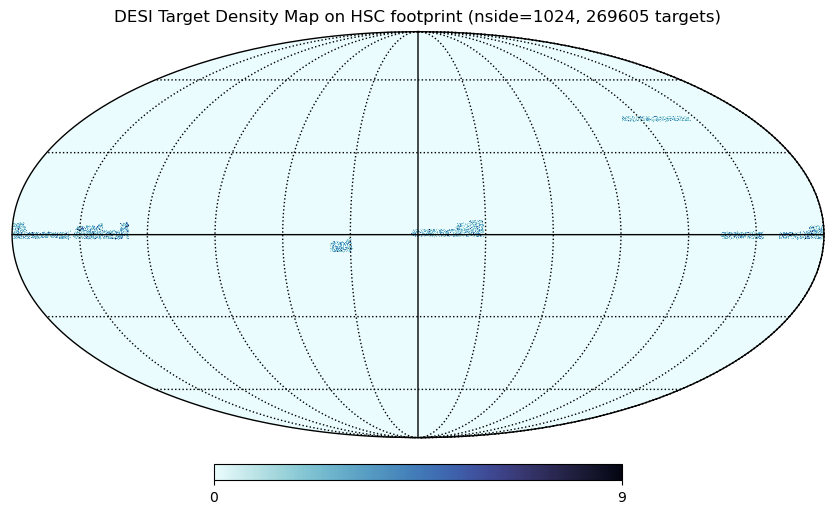

In [146]:
## plot DESI target density map
desi_sim = Table.read(f'{dir_desi}desi_targets_sim_LRG_v2.fits')
ra = desi_sim['ra']
dec = desi_sim['dec']
theta = np.radians(90.0 - dec)
phi = np.radians(ra)
pix_target_desi = hp.ang2pix(nside_hsc, theta, phi, nest=True)
npix = hp.nside2npix(nside_hsc)
density_map = np.bincount(pix_target_desi, minlength=npix)

hp.mollview(
    density_map, 
    nest=True, 
    cmap=cmo.ice_r, 
    title=f'DESI Target Density Map on HSC footprint (nside={nside_hsc}, {len(desi_sim)} targets)'
    )
hp.graticule()
plt.show()

## i mag probability density of HSC

-----------------------------------

Generating the probability density of i mag in HSC to sample sources from the Buzzard Catalog.

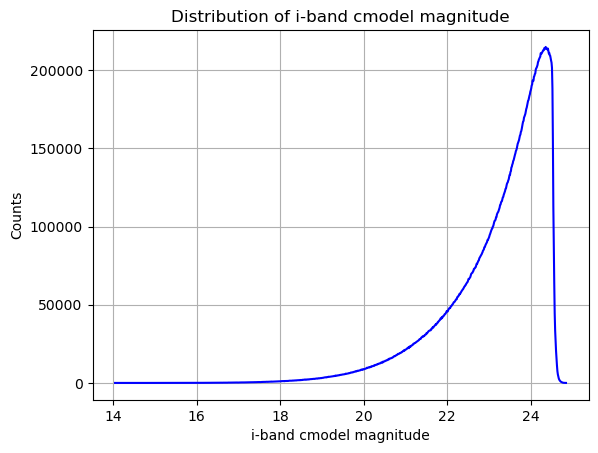

In [ ]:
## let's get the probability distribution of HSC
i_mag_cm = hsc_tbl_all[1]['i_cm_mag'].read()
counts_imagpdf, bin_edges_imagpdf = np.histogram(i_mag_cm, bins=1000)

plt.plot(bin_edges_imagpdf[:-1], counts_imagpdf, label='HSC i-band cmodel magnitude', color='blue')
counts_imagpdf = counts_imagpdf / np.sum(counts_imagpdf)
plt.title('Distribution of i-band cmodel magnitude')
plt.xlabel('i-band cmodel magnitude')
plt.ylabel('Counts')
plt.grid()

Perform intelligent data sampling from the Buzzard catalog magnitudes

In [149]:
mag_index = list(filters).index('DECAM_i')
tbpix_keys = list(tiles_buzzard_to_hsc.keys())
buzzard_truth = []
mag_truth = []
outdir = f'hsc{patch_id}/temp_tiles/'
Path(outdir).mkdir(parents=True, exist_ok=True)

for index, (tbpix, thpixs) in enumerate(tiles_buzzard_to_hsc.items()):
    print(
        f"Processing tile {tbpix} with {len(thpixs)} HSC tiles ({index+1}/{len(tbpix_keys)})"
        )
    with fio.FITS(bc.fetch_truth(tbpix)) as f:
        truth = f[1].read(columns=['ID', 'RA', 'DEC', 'PX', 'PY', 'PZ'])
        ra_truth = truth['RA']
        dec_truth = truth['DEC']
        theta_truth = np.radians(90.0 - dec_truth)
        phi_truth = np.radians(ra_truth)

    with fio.FITS(bc.fetch_surveymag(tbpix)) as f:
        mags = f[1].read(columns=['LMAG', 'Z'])
    
    imag = mags['LMAG'][:, mag_index]
    mags = rfn.drop_fields(mags, 'LMAG')
    mags = rfn.append_fields(mags, 'IMAG', imag, usemask=False)

    pix_truth_hsc = hp.ang2pix(nside_hsc, theta_truth, phi_truth, nest=True)
    print(
        f"Found {len(truth)} sources in tile {tbpix} with {len(mags)} magnitudes. Finished loading files\n"
        )
    
    mid_truth = []
    mid_mag = []
    cnt_wrong_dens = 0
    for k, thp in enumerate(thpixs):

        in_thp = pix_truth_hsc == thp
        n_draw = int(hsc_hp_map[thp]) 
        # here : add some slight noise to the density 
        #n_draw = int(n_draw + n_draw * np.random.normal(0, 1/n_draw**2))

        if not np.any(in_thp) or n_draw == 0:
            print(f"Skipping tile {thp} with no sources or no HSC sources")
            continue

        # Sample randomly from sources in this tile
        indices_in_thp = np.where(in_thp)[0]
        # Assign each imag value to a bin
        bin_indices = np.digitize(imag[indices_in_thp], bin_edges_imagpdf) - 1
        valid = (bin_indices >= 0) & (bin_indices < len(counts_imagpdf))

        if not np.any(valid):
            print(f"Skipping tile {thp} with no valid sources")
            continue

        bin_indices = bin_indices[valid]
        indices_in_thp = indices_in_thp[valid]
        #try:
        #    probs = counts_imagpdf[bin_indices] / np.sum(counts_imagpdf[bin_indices])
        #    nonzero_mask = probs > 0
        #    probs = probs[nonzero_mask]
        #except ZeroDivisionError:
        #    print(f"ZeroDivisionError for tile {thp} with {len(indices_in_thp)} sources")
        #    probs = np.ones(len(bin_indices)) / len(bin_indices)
        #    nonzero_mask = np.ones(len(bin_indices), dtype=bool)
        #    cnt_wrong_dens += 1
        probs = counts_imagpdf[bin_indices] / np.sum(counts_imagpdf[bin_indices])
        indices_in_thp = indices_in_thp[probs > 0]
        probs = probs[probs > 0]

        n_to_sample = min(n_draw, len(indices_in_thp))
        if len(indices_in_thp) < n_draw:
            cnt_wrong_dens +=1

        if k % int(len(thpixs)//5) == 0:
            print(
                f"Tile {thp} has {len(indices_in_thp)} sources, "
                f"expecting to sample {n_to_sample} with probs {[f'{p:.2e}' for p in probs[:5]]}, "
                f"valid sources percentage {np.sum(valid)/len(valid)*100:.1f}%, "
                f"progress {k}/{len(thpixs)} [{100*(k+1)/len(thpixs):.1f}%]"
                )
            
        probs /= probs.sum()

        select_ind = np.random.choice(
            # here we give the probability of sampling to the sources based on the magnitude distribution
            indices_in_thp, 
            size=n_to_sample, 
            replace=False, 
            p=probs
            )

        mini_truth = truth[select_ind]
        mini_mag = mags[select_ind]
        mid_truth.append(mini_truth)
        mid_mag.append(mini_mag)
    
    print(f'\nNumber of wrong densities: {cnt_wrong_dens}')
    print(f'Expected counts = {np.sum(hsc_hp_map[thpixs])}, Found counts = {sum(len(mt) for mt in mid_truth)}\n')

    # Concatenate the results
    tile_truth_table = Table(np.concatenate(mid_truth))
    tile_truth_table['RA'] -= offset_ra
    tile_truth_table['DEC'] -= offset_dec
    mid_mag_conc = np.concatenate(mid_mag)
    tile_truth_table['IMAG'] = mid_mag_conc['IMAG']
    tile_truth_table['Z'] = mid_mag_conc['Z']
    del mid_mag_conc
    tile_truth_table.write(f"{outdir}/tile_{tbpix}.fits", overwrite=True)

tables = [Table.read(f) for f in Path(outdir).glob("*.fits")]
final_table = vstack(tables)
final_table.write(f'hsc{patch_id}/test_hsc_buzzard.fits', overwrite=True)

Processing tile 3 with 293 HSC tiles (1/31)
Found 15803210 sources in tile 3 with 15803210 magnitudes. Finished loading files

Tile 64885 has 401 sources, expecting to sample 105 with probs ['2.83e-04', '6.02e-04', '5.71e-04', '7.50e-04', '1.39e-03'], valid sources percentage 45.4%, progress 0/293 [0.3%]
Tile 65241 has 395 sources, expecting to sample 243 with probs ['1.63e-05', '1.22e-04', '1.46e-04', '8.24e-05', '4.76e-07'], valid sources percentage 44.9%, progress 58/293 [20.1%]
Tile 65329 has 437 sources, expecting to sample 18 with probs ['1.65e-05', '8.95e-06', '3.71e-05', '4.33e-05', '9.72e-05'], valid sources percentage 42.1%, progress 116/293 [39.9%]
Tile 65397 has 449 sources, expecting to sample 235 with probs ['4.13e-05', '1.50e-04', '3.31e-03', '6.89e-07', '2.71e-03'], valid sources percentage 46.1%, progress 174/293 [59.7%]
Tile 65463 has 363 sources, expecting to sample 303 with probs ['2.27e-03', '3.66e-03', '3.91e-03', '7.37e-05', '7.37e-05'], valid sources percentage 

In [79]:
dir_hsc = 'v2/hsc/'
Path(dir_hsc).mkdir(parents=True, exist_ok=True)

In [ ]:
tbl = vstack([Table.read(f'hsc{patch_id}/test_hsc_buzzard.fits') for patch_id in range(1, 3)])
tbl.write(f'{dir_hsc}hscy3_sim_v2.fits', overwrite=True)

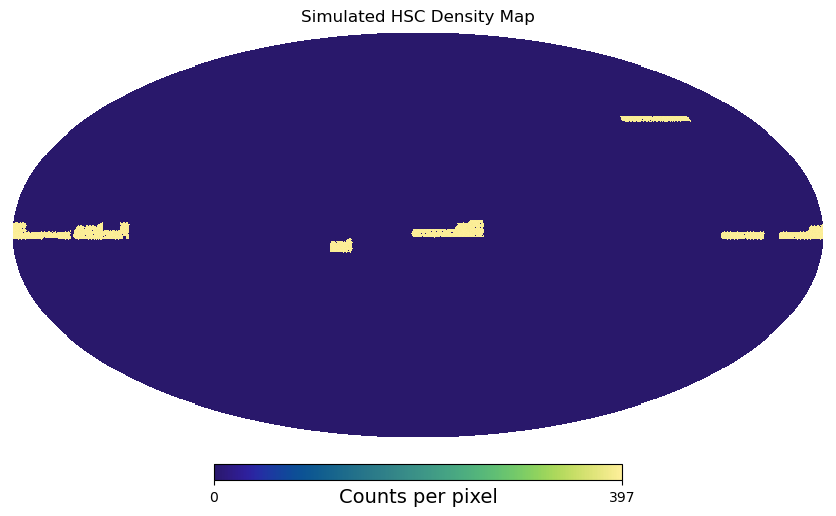

In [81]:
tbl_hsc = Table.read(f'{dir_hsc}hscy3_sim_v2.fits')
ra = tbl_hsc['RA']
dec = tbl_hsc['DEC']
theta = np.radians(90.0 - dec)
phi = np.radians(ra)
# Convert to healpix pixel indices
hsc_pix_indices_sim = hp.ang2pix(nside_hsc, theta, phi, nest=True)
# Create a healpy map
hsc_hp_map_sim = np.bincount(hsc_pix_indices_sim, minlength=npix_hsc)
hp.mollview(
    hsc_hp_map_sim,
    title="Simulated HSC Density Map",
    unit="Counts per pixel",
    norm="hist",
    cmap=cmo.haline,
    nest=True,
)

In [82]:
hsc_sim = Table.read(f'{dir_hsc}hscy3_sim_v2.fits')

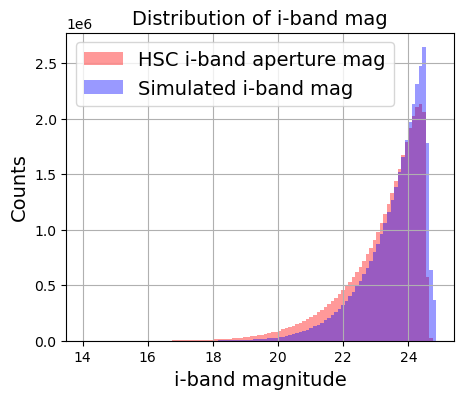

In [85]:
# === Plotting the distribution of i-band magnitude ===
plt.figure(figsize=(5, 4))
plt.hist(
    i_mag_cm,
    bins=100,
    color='red',
    alpha=0.4,
    label='HSC i-band aperture mag',
)
plt.hist(
    hsc_sim['IMAG'],
    bins=100,
    color='blue',
    alpha=0.4,
    label='Simulated i-band mag',
)
plt.grid()
plt.xlabel('i-band magnitude', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.title('Distribution of i-band mag', fontsize=14)
plt.legend(fontsize=14)

Text(0.5, 1.0, 'Redshift distribution - simulated vs HSC\n(0.983 sim/HSC density ratio)')

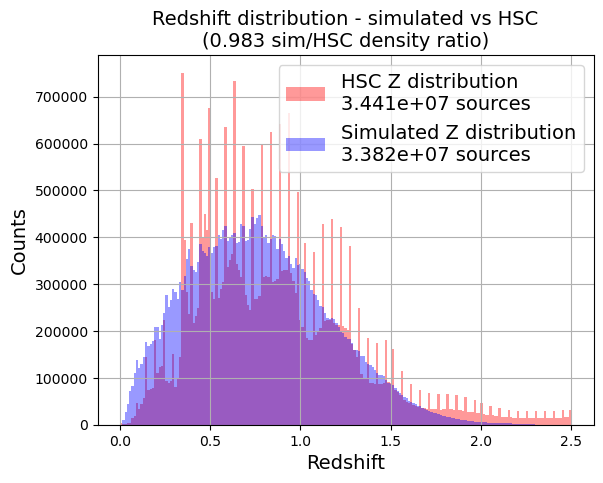

In [86]:
zbins = np.linspace(0, 2.5, 200)
zall = hsc_tbl_all[1]['dnnz_photoz_best'].read()

plt.hist(
    zall,
    bins=zbins,
    color='red',
    alpha=0.4,
    label=f'HSC Z distribution\n{len(zall):.3e} sources',
)
plt.hist(
    hsc_sim['Z'],
    bins=zbins,
    color='blue',
    alpha=0.4,
    label=f'Simulated Z distribution\n{len(hsc_sim["Z"]):.3e} sources',
)

plt.grid()
plt.xlabel('Redshift', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.legend(fontsize=14)
plt.title(
    f'Redshift distribution - simulated vs HSC\n({len(hsc_sim["Z"])/len(zall):.3f} sim/HSC density ratio)',
    fontsize=14
    )

### Retained buzzard columns

--------------------

Truth files : 
- ID
- RA
- DEC
- P[X,Y,Z]
- LMAG[DECam i band]

Survey mag files :
- LMAG
- Z

## Buzzard columns

### 1] Truth files
- P[X,Y,Z] -- 3d position [Mpc/h]
- V[X,Y,Z] -- 3d velocity [km/s]
- Z_COS -- Cosmological redshift
- Z -- Redshift including RSD (Currently has a bug, should use Z in the 'surveymag' files as described below)
- MAG_R -- SDSS r-band absolute magnitude
- DIST8 -- R_delta (see addgals paper) [Mpc/h]
- M200 -- M_200 of host halo [M_sun/h]
- R200 -- R_200 of host halo [Mpc/h]
- RHALO -- Distance to nearest halo [Mpc/h]
- HALOID -- Halo id of host halo
- CENTRAL -- True for central galaxies
- SEDID -- SDSS training set index for SED assigned to galaxy
- TMAG -- Noiseless, unlensed, grizy apparent magnitudes in DECAM bandpasses [mag]
- AMAG -- Noiseless, unlensed, grizy absolute magnitudes in DECAM bandpasses [mag]
- TSIZE -- Unlensed half light radius [arcsec]
- TE -- Unlensed ellipticities
- COMOVING_SIZE -- Comoving size [Mpc]
- ID -- Unique galaxy ID
- TRA -- Unlensed RA [deg]
- TDEC -- Unlensed dec [deg]
- EPSILON -- Lensed ellipticities
- SIZE -- Lensed size [arcmin]
- KAPPA -- Convergence
- MU -- Magnification
- W -- Rotation
- GAMMA1 -- True gravitational shear along local RA direction
- GAMMA2 -- True gravitational shear along local DEC direction
- DEC -- Lensed DEC [deg]
- RA -- Lensed RA [deg]
- LMAG -- Lensed apparent DECAM grizy magnitudes

### 2] Mag files

- DECAM u
- DECAM g
- DECAM r
- DECAM i
- DECAM z
- DECAM Y
- Vista Z
- Vista Y
- Vista J
- Vista H
- Vista K
- Rubin LSST u
- Rubin LSST g
- Rubin LSST r
- Rubin LSST i
- Rubin LSST z
- Rubin LSST y
- WFIRST Y
- WFIRST J
- WFIRST H
- WFIRST K
- WISE W1
- WISE W2
- TMAG -- Noiseless, unlensed apparent magnitudes [mag]
- AMAG -- Noiseless, unlensed absolute magnitudes [mag]
- LMAG -- Noiseless, lensed apparent magnitudes [mag]
- OMAG -- Not currently used
- OMAGERR -- Not currently used
- FLUX -- Not currently used
- IVAR -- Not currently used
- Z -- Redshift including RSD (Use this instead of the redshift in the truth files!)